In [1]:
!pip install langchain langgraph langchain_openai langchain_groq --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 5.9 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata
#os.environ["OPENAI_API_KEY"]"" = userdata.get('OPEN_API_KEY')
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [3]:
# Import ChatModels
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

# Import Langgraph
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import display, Image

from typing_extensions import TypedDict, Optional, Literal
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [4]:
# Initialize a LLM
#llm=ChatOpenAI(model="o1-mini")

llm = ChatGroq(model="qwen-2.5-32b")

## Specific LLM to generate code
llm_code = ChatGroq(model="qwen-2.5-coder-32b")


In [5]:
prompt = ChatPromptTemplate.from_messages([
    ("system","You are a helpful software development assistant"),
    ("human","{input}")
])

chain = prompt | llm | StrOutputParser()

In [6]:
# Initialize the state
class State(TypedDict):
  requirements: str
  user_stories: str
  design_doc: str
  code: str
  test_cases: str
  qa_result: Literal["Passed", "Failed"]
  feedback: str

In [8]:
# Create the nodes with required functionalities

def auto_generate_user_stories(state: State)-> State:
  user_stories_prompt = f"Generate the relevant user stories based on the requirements: {state['requirements']}"
  state['user_stories'] = chain.invoke({"input": user_stories_prompt})
  return state

def product_owner_review(state:State) -> State:
  product_owner_review_prompt = f"Review the following user stories and respond with 'Approved' or 'Feedback Needed' :\n {state['user_stories']}"
  review = chain.invoke({"input": product_owner_review_prompt})
  state["feedback"] = "Approved" if "Approved" in review else "Feedback"
  return state

def revise_user_stories(state:State) -> State:
  revise_user_stories_prompt = f"Revise the following user stories based on the feedback given\
  \n User Stories: {state['user_stories']}\
  \n Feedback : {state['feedback']} \
  "
  state["user_stories"] = chain.invoke({"input": revise_user_stories_prompt})
  return state

def create_design_docs(state: State) -> State:
    input_text = f"Create functional and technical design documents for: {state['user_stories']}"
    state["design_docs"] = chain.invoke({"input": input_text})
    return state

def design_review(state: State) -> Literal["Approved", "Feedback"]:
    input_text = f"Review the following design and reply with 'Approved' or 'Feedback needed': {state['design_docs']}"
    output = chain.invoke({"input": input_text})
    return "Approved" if "Approved" in output else "Feedback"

def generate_code(state: State) -> State:
    input_text = f"Generate code using this design: {state['design_docs']}"
    state["code"] = chain.invoke({"input": input_text})
    return state

def code_review(state: State) -> Literal["Approved", "Feedback"]:
    input_text = f"Review this code and reply with 'Approved' or 'Feedback needed': {state['code']}"
    output = chain.invoke({"input": input_text})
    return "Approved" if "Approved" in output else "Feedback"

def fix_code_after_review(state: State) -> State:
    input_text = f"Fix this code based on code review feedback: {state['code']}"
    state["code"] = chain.invoke({"input": input_text})
    return state

def security_review(state: State) -> Literal["Approved", "Feedback"]:
    input_text = f"Review the code for security issues and respond with 'Approved' or 'Feedback needed': {state['code']}"
    output = chain.invoke({"input": input_text})
    return "Approved" if "Approved" in output else "Feedback"

def fix_code_after_security(state: State) -> State:
    input_text = f"Apply security fixes to the code: {state['code']}"
    state["code"] = chain.invoke({"input": input_text})
    return state

def write_test_cases(state: State) -> State:
    input_text = f"Write test cases for the following code: {state['code']}"
    state["test_cases"] = chain.invoke({"input": input_text})
    return state

def test_case_review(state: State) -> Literal["Approved", "Feedback"]:
    input_text = f"Review these test cases and respond with 'Approved' or 'Feedback needed': {state['test_cases']}"
    output = chain.invoke({"input": input_text})
    return "Approved" if "Approved" in output else "Feedback"

def fix_test_cases(state: State) -> State:
    input_text = f"Fix the test cases based on feedback: {state['test_cases']}"
    state["test_cases"] = chain.invoke({"input": input_text})
    return state

def qa_testing(state: State) -> State:
    # Simulate QA outcome (real version would integrate actual tests)
    input_text = f"Review these qa test cases and respond with 'Approved' or 'Feedback needed': {state['test_cases']}"
    output = chain.invoke({"input": input_text})
    return "Approved" if "Approved" in output else "Feedback"

def fix_after_qa(state: State) -> State:
    input_text = f"Fix the code after QA failure: {state['code']}"
    state["code"] = chain.invoke({"input": input_text})
    state["qa_result"] = "Passed"
    return state

def deployment(state: State) -> State:
    print("Deploying application...")
    return state

def monitoring_feedback(state: State) -> State:
    input_text = f"Simulate monitoring and feedback from production for the app."
    state["feedback"] = chain.invoke({"input": input_text})
    return state

def maintenance_and_updates(state: State) -> State:
    print("Performing maintenance and applying updates...")
    return state

In [44]:
from langchain_core.runnables import RunnableLambda

In [67]:
# Create the workflow
graph = StateGraph(State)

# Add Nodes
graph.add_node("Generate_User_Stories", auto_generate_user_stories)
graph.add_node("Product_Owner_Review", product_owner_review)
graph.add_node("Revise_User_Stories", revise_user_stories)
graph.add_node("GenerateDesignDocs", create_design_docs)
graph.add_node("ReviewDesign", design_review)
graph.add_node("GenerateCode", generate_code)
graph.add_node("CodeReview", code_review)
graph.add_node("Fix Code After Code Review", fix_code_after_review)
graph.add_node("Security Review", security_review)
graph.add_node("Fix Code After Security", fix_code_after_security)
graph.add_node("Write Tests", write_test_cases)
graph.add_node("Review Tests", test_case_review)
graph.add_node("Fix Tests", fix_test_cases)
graph.add_node("QA", qa_testing)
graph.add_node("Fix Code After QA", fix_after_qa)
graph.add_node("Deploy", deployment)
# graph.add_node("Monitor", monitoring_feedback)
# graph.add_node("Maintenance", maintenance_and_updates)

# Add Edges
graph.add_edge(START, "Generate_User_Stories")
graph.add_edge("Generate_User_Stories", "Product_Owner_Review")
graph.add_conditional_edges("Product_Owner_Review",
  lambda state: state.get("feedback"),
 {
    "Approved": "GenerateDesignDocs",
    "Feedback": "Revise_User_Stories"
})
graph.add_edge("Revise_User_Stories","Generate_User_Stories")
graph.add_edge("GenerateDesignDocs", "ReviewDesign")
graph.add_conditional_edges("ReviewDesign",
  #lambda state: state.get("feedback"),
  RunnableLambda(design_review),
 {
    "Approved": "GenerateCode",
    "Feedback": "GenerateDesignDocs"
})

graph.add_edge("GenerateCode", "CodeReview")
graph.add_conditional_edges("CodeReview",
  RunnableLambda(code_review),
  {
    "Approved": "Security Review",
    "Feedback": "Fix Code After Code Review"
})
graph.add_edge("Fix Code After Code Review", "GenerateCode")
graph.add_conditional_edges("Security Review",
  RunnableLambda(security_review),
  {
    "Approved": "Write Tests",
    "Feedback": "Fix Code After Security"
})
graph.add_edge("Fix Code After Security", "Security Review")
graph.add_edge("Write Tests", "Review Tests")
graph.add_conditional_edges("Review Tests",
  RunnableLambda(test_case_review),
  {
    "Approved": "QA",
    "Feedback": "Fix Tests"
})

graph.add_edge("Fix Tests", "Review Tests")
graph.add_conditional_edges("QA",
  RunnableLambda(qa_testing),
  {
    "Approved": "Deploy",
    "Feedback": "Fix Code After QA"
})
graph.add_edge("Fix Code After QA", "QA")
graph.add_edge("Deploy", END)

# graph.add_edge("QA", "Deploy", condition=lambda s: s["qa_result"] == "Passed")
# graph.add_edge("QA", "FixQA", condition=lambda s: s["qa_result"] == "Failed")
# graph.add_edge("FixQA", "QA")
# graph.add_edge("Deploy", "Monitor")
# graph.add_edge("Monitor", "Maintenance")
# graph.add_edge("Maintenance", END)
g = graph.compile()

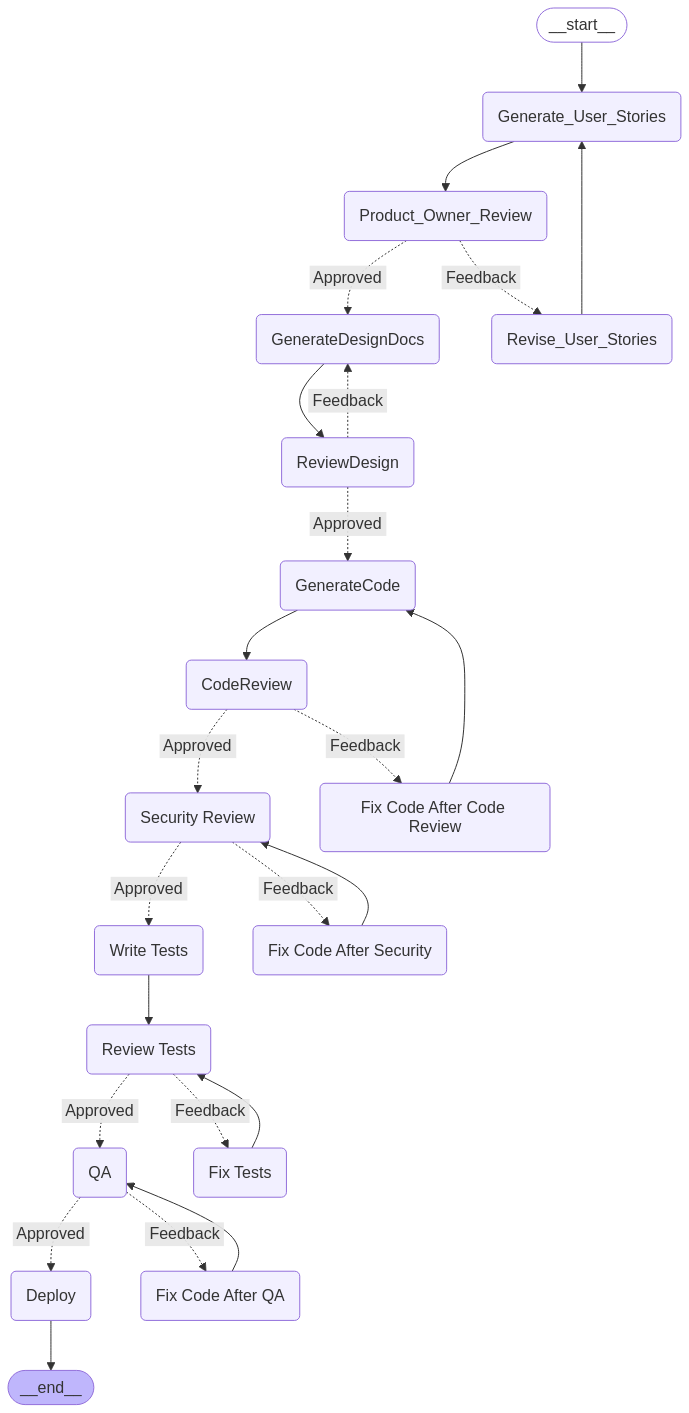

In [68]:
# Show workflow
display(Image(g.get_graph(xray=True).draw_mermaid_png()))
#workflow.get_graph().print_ascii()

In [27]:
from IPython.display import Markdown

final_state = g.invoke({"requirements":"I want to train a machine learning model on the given dataset. I want end to end operation in this cycle."})

In [28]:
Markdown(final_state['user_stories'])

Based on your requirements, it sounds like you are looking to develop a system that handles the entire workflow from data preparation to model deployment for a machine learning project. Below are some user stories that could help define the scope and functionality of such a system:

### User Story: Data Import and Preparation
1. As a user, I want to be able to upload a dataset to the system, so that I can start preparing the data for training.
2. As a user, I want to clean the dataset by removing or imputing missing values, so that the data is suitable for training.
3. As a user, I want to handle outliers in the dataset, so that they do not negatively impact the model's performance.
4. As a user, I want to perform feature scaling or normalization, so that the model can process the data effectively.
5. As a user, I want to split the dataset into training and testing sets, so that I can evaluate the model's performance accurately.

### User Story: Model Training
6. As a user, I want to select a machine learning algorithm suitable for my dataset, so that I can train a model.
7. As a user, I want to configure hyperparameters for the selected algorithm, so that I can optimize the model's performance.
8. As a user, I want to train the model on the prepared training dataset, so that it can learn patterns from the data.
9. As a user, I want to validate the model's performance on a separate validation set, so that I can make adjustments if necessary.

### User Story: Model Evaluation
10. As a user, I want to evaluate the trained model on the testing dataset, so that I can assess its performance.
11. As a user, I want to receive metrics such as accuracy, precision, recall, and F1 score, so that I can understand the model's strengths and weaknesses.

### User Story: Model Deployment
12. As a user, I want to deploy the model to a production environment, so that it can be used to make predictions on new data.
13. As a user, I want to be able to input new data into the deployed model, so that I can get real-time predictions.

### User Story: Model Monitoring and Maintenance
14. As a user, I want to monitor the performance of the deployed model over time, so that I can ensure it continues to perform well.
15. As a user, I want to be able to retrain the model with new data, so that it can adapt to changes in the underlying data distribution.

### User Story: Interoperability and Documentation
16. As a user, I want to export the trained model in a format that is usable in other applications, so that I can integrate it into my existing systems.
17. As a user, I want to generate documentation for the model's development process, so that I can have a record of how the model was created and trained.

These user stories cover the end-to-end cycle of training and deploying a machine learning model, from data preparation to monitoring the model's performance in production.